# Math Intuition for Machine Learning

This is a **reference notebook**, not a lesson. Open it whenever you encounter a mathematical function in the course and want to see what it looks like and why it matters.

Every function here appears repeatedly across ML. Understanding their shapes gives you instant intuition for why algorithms behave the way they do — you don't need to memorize formulas, just know what each curve does to numbers.

In [ ]:
# Colab setup - run this cell first if you're on Google Colab
try:
    import google.colab
    print("Colab environment ready! All required packages are pre-installed.")
except ImportError:
    pass  # Not on Colab, no action needed

In [1]:
# === VISUALIZATION HELPERS (collapse this cell) ===

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = {
    'blue': '#2563eb', 'red': '#dc2626', 'green': '#059669',
    'amber': '#d97706', 'purple': '#7c3aed', 'cyan': '#0891b2',
    'gray': '#6b7280',
}
C = COLORS


def plot_function(func, x_range, title, ylabel='f(x)', key_points=None,
                  annotations=None, color=None, figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    x = np.linspace(*x_range, 500)
    y = func(x)
    c = color or C['blue']
    ax.plot(x, y, color=c, linewidth=2.5)
    ax.axhline(y=0, color='#d1d5db', linewidth=0.8)
    ax.axvline(x=0, color='#d1d5db', linewidth=0.8)
    if key_points:
        for px, py, label in key_points:
            ax.plot(px, py, 'o', color=C['red'], markersize=8, zorder=5)
            ax.annotate(label, (px, py), textcoords="offset points",
                        xytext=(12, 10), fontsize=10, color=C['gray'])
    if annotations:
        for text, xy, xytext in annotations:
            ax.annotate(text, xy=xy, xytext=xytext, fontsize=10,
                        arrowprops=dict(arrowstyle='->', color=C['gray']),
                        color=C['gray'], ha='center')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_comparison(funcs, labels, x_range, title, ylabel='f(x)',
                    colors=None, figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    x = np.linspace(*x_range, 500)
    default_colors = [C['blue'], C['red'], C['green'], C['amber']]
    colors = colors or default_colors
    for func, label, c in zip(funcs, labels, colors):
        ax.plot(x, func(x), color=c, linewidth=2.5, label=label)
    ax.axhline(y=0, color='#d1d5db', linewidth=0.8)
    ax.axvline(x=0, color='#d1d5db', linewidth=0.8)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_neg_log_punishment():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    p = np.linspace(0.01, 1.0, 200)
    loss = -np.log(p)
    axes[0].plot(p, loss, color=C['red'], linewidth=2.5)
    for prob in [0.95, 0.5, 0.1, 0.01]:
        l = -np.log(prob)
        axes[0].plot(prob, l, 'o', color=C['blue'], markersize=8, zorder=5)
        axes[0].annotate(f'p={prob} → loss={l:.2f}', (prob, l),
                         textcoords="offset points", xytext=(15, 5), fontsize=9)
    axes[0].set_xlabel('Probability of correct class', fontsize=12)
    axes[0].set_ylabel('Loss = -log(p)', fontsize=12)
    axes[0].set_title('Cross-Entropy: The Punishment Curve', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.2)

    axes[1].axis('off')
    table_data = [['P(correct)', '-log(p)', 'Meaning']]
    rows = [
        (0.95, 'Confident & right'),
        (0.80, 'Mostly right'),
        (0.50, 'Coin flip'),
        (0.20, 'Mostly wrong'),
        (0.05, 'Confident & wrong'),
        (0.01, 'Very confident & wrong'),
    ]
    for prob, meaning in rows:
        table_data.append([f'{prob:.2f}', f'{-np.log(prob):.2f}', meaning])
    table = axes[1].table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8)
    for j in range(3):
        table[0, j].set_facecolor('#1f2937')
        table[0, j].set_text_props(color='white', fontweight='bold')
    severity_colors = ['#d4edda', '#d4edda', '#fff3cd', '#f8d7da', '#f8d7da', '#f8d7da']
    for i, clr in enumerate(severity_colors):
        for j in range(3):
            table[i + 1, j].set_facecolor(clr)
    axes[1].set_title('The Punishment Table', fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


def plot_exp_log_mirror():
    fig, ax = plt.subplots(figsize=(8, 8))
    x_exp = np.linspace(-2, 2.5, 200)
    x_log = np.linspace(0.05, 7, 200)
    x_id = np.linspace(-1, 5, 100)
    ax.plot(x_exp, np.exp(x_exp), color=C['blue'], linewidth=2.5, label='y = eˣ')
    ax.plot(x_log, np.log(x_log), color=C['red'], linewidth=2.5, label='y = ln(x)')
    ax.plot(x_id, x_id, color='#d1d5db', linewidth=1.5, linestyle='--', label='y = x (mirror line)')
    ax.axhline(y=0, color='#e5e7eb', linewidth=0.8)
    ax.axvline(x=0, color='#e5e7eb', linewidth=0.8)
    for px, py in [(0, 1), (1, np.e)]:
        ax.plot(px, py, 'o', color=C['blue'], markersize=7, zorder=5)
        ax.plot(py, px, 's', color=C['red'], markersize=7, zorder=5)
        ax.plot([px, py], [py, px], ':', color='#9ca3af', linewidth=1)
    ax.set_xlim(-2.5, 5)
    ax.set_ylim(-2.5, 5)
    ax.set_aspect('equal')
    ax.legend(fontsize=12, loc='lower right')
    ax.set_title('Exponential and Logarithm are Mirror Images',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_sigmoid_anatomy():
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.linspace(-8, 8, 500)
    y = 1 / (1 + np.exp(-x))
    ax.plot(x, y, color=C['blue'], linewidth=2.5)
    ax.axhspan(0.9, 1.0, alpha=0.1, color=C['green'])
    ax.axhspan(0.0, 0.1, alpha=0.1, color=C['red'])
    ax.axhspan(0.4, 0.6, alpha=0.08, color=C['amber'])
    ax.plot(0, 0.5, 'o', color=C['red'], markersize=10, zorder=5)
    ax.annotate('x=0 → σ=0.5\n(maximum uncertainty)', (0, 0.5),
                textcoords="offset points", xytext=(20, -25), fontsize=10,
                arrowprops=dict(arrowstyle='->', color=C['gray']))
    ax.axhline(y=1, color=C['green'], linestyle='--', alpha=0.5)
    ax.axhline(y=0, color=C['red'], linestyle='--', alpha=0.5)
    ax.text(5, 0.95, '"class 1"', fontsize=11, color=C['green'], fontweight='bold')
    ax.text(-7, 0.05, '"class 0"', fontsize=11, color=C['red'], fontweight='bold')
    ax.text(3, 0.5, 'uncertain zone', fontsize=10, color=C['amber'], fontstyle='italic')
    ax.set_xlabel('x (raw logit)', fontsize=12)
    ax.set_ylabel('σ(x) = probability', fontsize=12)
    ax.set_title('Sigmoid: Squashes Any Number to (0, 1)',
                 fontsize=14, fontweight='bold')
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_relu_vs_sigmoid():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.linspace(-5, 5, 500)

    sig = 1 / (1 + np.exp(-x))
    sig_grad = sig * (1 - sig)
    axes[0].plot(x, sig, color=C['blue'], linewidth=2.5, label='σ(x)')
    axes[0].plot(x, sig_grad, color=C['red'], linewidth=2,
                 linestyle='--', label="σ'(x) gradient")
    axes[0].axhline(y=0, color='#d1d5db', linewidth=0.8)
    axes[0].set_title('Sigmoid as Activation', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.2)
    axes[0].annotate('max gradient = 0.25\n→ vanishes after many layers!',
                     (0, 0.25), textcoords="offset points", xytext=(30, 30),
                     fontsize=9, color=C['gray'],
                     arrowprops=dict(arrowstyle='->', color=C['gray']))

    relu = np.maximum(0, x)
    relu_grad = (x > 0).astype(float)
    axes[1].plot(x, relu, color=C['green'], linewidth=2.5, label='ReLU(x)')
    axes[1].plot(x, relu_grad, color=C['red'], linewidth=2,
                 linestyle='--', label="ReLU'(x) gradient")
    axes[1].axhline(y=0, color='#d1d5db', linewidth=0.8)
    axes[1].set_title('ReLU as Activation', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.2)
    axes[1].annotate('gradient = 1 always\n→ no vanishing!',
                     (3, 1), textcoords="offset points", xytext=(20, 30),
                     fontsize=9, color=C['gray'],
                     arrowprops=dict(arrowstyle='->', color=C['gray']))
    axes[1].annotate('"dead zone"\ngradient = 0',
                     (-3, 0), textcoords="offset points", xytext=(-30, 30),
                     fontsize=9, color=C['gray'],
                     arrowprops=dict(arrowstyle='->', color=C['gray']))

    plt.suptitle('Why ReLU Replaced Sigmoid for Hidden Layers',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_softmax_behavior():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    scenarios = [
        ([2.0, 1.0, 0.5, -1.0], 'Moderate logits'),
        ([5.0, 1.0, 0.5, -1.0], 'One dominant logit'),
        ([1.1, 1.0, 0.9, 0.8], 'Similar logits'),
    ]
    labels = ['A', 'B', 'C', 'D']
    bar_colors = [C['blue'], C['red'], C['green'], C['amber']]
    for ax, (logits, title) in zip(axes, scenarios):
        logits_np = np.array(logits)
        probs = np.exp(logits_np) / np.exp(logits_np).sum()
        bars = ax.bar(labels, probs, color=bar_colors, edgecolor='white', linewidth=1.5)
        for bar, p in zip(bars, probs):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{p:.2f}', ha='center', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.set_title(f'{title}\nlogits = {logits}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Probability')
        ax.axhline(y=1 / len(logits), color='gray', linestyle=':', alpha=0.4)
    plt.suptitle('Softmax: How Logits Become Probabilities',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_reference_card():
    funcs = [
        (lambda x: 2 * x + 1, 'Linear: y = mx + b', (-3, 3), 'Straight line\nnn.Linear, regression'),
        (lambda x: x ** 2, 'Quadratic: y = x²', (-3, 3), 'Bowl shape\nMSE loss landscape'),
        (lambda x: np.exp(x), 'Exponential: y = eˣ', (-2, 3), 'Explosive growth\nInside softmax'),
        (lambda x: np.log(np.clip(x, 0.01, None)), 'Logarithm: y = ln(x)', (0.01, 5),
         'Slow growth\nCross-entropy loss'),
        (lambda x: 1 / (1 + np.exp(-x)), 'Sigmoid: σ(x)', (-6, 6),
         'S-curve to (0,1)\nBinary classification'),
        (lambda x: np.maximum(0, x), 'ReLU: max(0, x)', (-3, 3),
         'Dead below zero\nHidden layer activation'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    card_colors = [C['blue'], C['red'], C['green'], C['amber'], C['purple'], C['cyan']]
    for i, (func, title, x_range, desc) in enumerate(funcs):
        ax = axes[i]
        x = np.linspace(*x_range, 300)
        ax.plot(x, func(x), color=card_colors[i], linewidth=2.5)
        ax.axhline(y=0, color='#d1d5db', linewidth=0.8)
        ax.axvline(x=0, color='#d1d5db', linewidth=0.8)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.text(0.05, 0.95, desc, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', color=C['gray'],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        ax.grid(True, alpha=0.15)
    plt.suptitle('ML Math Reference Card', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_ml_pipeline():
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # 1: Raw logits (bar chart)
    logits = np.array([2.0, 0.5, -1.0, 4.5, 0.1])
    classes = ['A', 'B', 'C', 'D', 'E']
    axes[0].bar(classes, logits, color=C['blue'], edgecolor='white')
    axes[0].set_title('1. Raw Logits\n(last layer output)', fontsize=11, fontweight='bold')
    axes[0].axhline(y=0, color='#d1d5db', linewidth=0.8)
    axes[0].set_ylabel('Value')

    # 2: Exponential
    exp_vals = np.exp(logits)
    axes[1].bar(classes, exp_vals, color=C['amber'], edgecolor='white')
    axes[1].set_title('2. eˣ applied\n(all positive, differences amplified)',
                      fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Value')

    # 3: Softmax (normalize)
    probs = exp_vals / exp_vals.sum()
    axes[2].bar(classes, probs, color=C['green'], edgecolor='white')
    for i, p in enumerate(probs):
        axes[2].text(i, p + 0.01, f'{p:.2f}', ha='center', fontsize=10, fontweight='bold')
    axes[2].set_title(f'3. Divide by sum\n(probabilities, sum = {probs.sum():.0f})',
                      fontsize=11, fontweight='bold')
    axes[2].set_ylim(0, 1.1)
    axes[2].set_ylabel('Probability')

    # 4: -log of correct class
    true_class = 3  # D
    p_correct = probs[true_class]
    loss = -np.log(p_correct)
    p_range = np.linspace(0.01, 1.0, 100)
    axes[3].plot(p_range, -np.log(p_range), color=C['red'], linewidth=2)
    axes[3].plot(p_correct, loss, 'o', color=C['blue'], markersize=12, zorder=5)
    axes[3].annotate(f'p={p_correct:.2f}\nloss={loss:.3f}',
                     (p_correct, loss), textcoords="offset points",
                     xytext=(15, 10), fontsize=11, fontweight='bold')
    axes[3].set_title('4. -log(p) at correct class\n(cross-entropy loss)',
                      fontsize=11, fontweight='bold')
    axes[3].set_xlabel('p')
    axes[3].set_ylabel('-log(p)')

    plt.suptitle('The Full Pipeline: Logits → Softmax → Cross-Entropy Loss',
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


print("Plotting helpers loaded!")

Plotting helpers loaded!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## How to Use This Notebook

Jump to whatever function you need. Each section shows the curve, explains what it does to numbers, and tells you where it appears in the course. The reference card at the end puts all six curves side by side for quick comparison.

## Linear: y = mx + b

The simplest function and the foundation of everything. A straight line where `m` controls steepness (slope) and `b` shifts it up or down. Every `nn.Linear` layer in PyTorch computes exactly this — just with matrices instead of single numbers.

Change the slope and it tilts. Change the bias and it shifts. That's literally what training does: gradient descent adjusts `m` and `b` until the line fits your data.

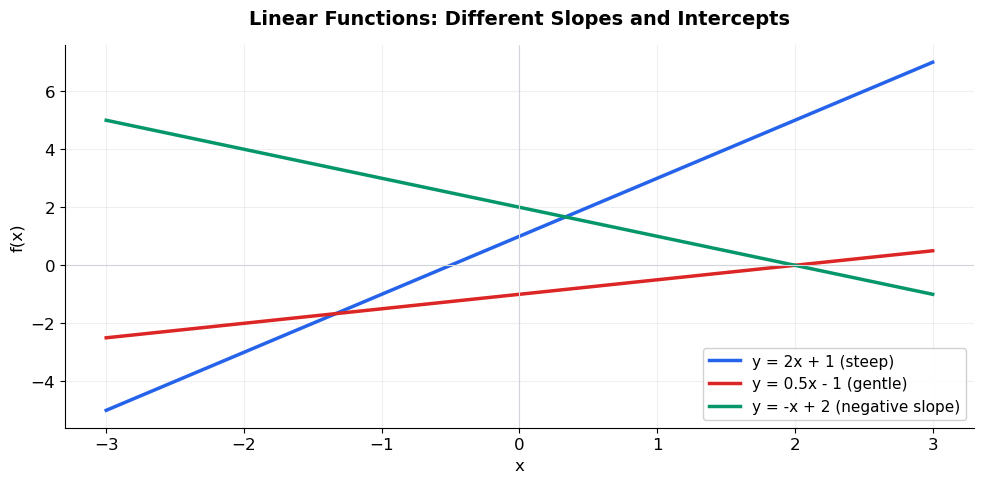

In [3]:
plot_comparison(
    funcs=[lambda x: 2*x + 1, lambda x: 0.5*x - 1, lambda x: -x + 2],
    labels=['y = 2x + 1 (steep)', 'y = 0.5x - 1 (gentle)', 'y = -x + 2 (negative slope)'],
    x_range=(-3, 3),
    title='Linear Functions: Different Slopes and Intercepts',
)

## Quadratic: y = x²

The bowl shape. When you hear "loss landscape" or "gradient descent rolling downhill," this is what people picture. MSE (Mean Squared Error) creates a quadratic loss surface — one smooth bowl with a single minimum at the bottom.

The key property: the farther you are from the minimum, the steeper the slope. Gradient descent takes big steps when far away and small steps when close. This is why it converges — the bowl naturally guides you to the bottom.

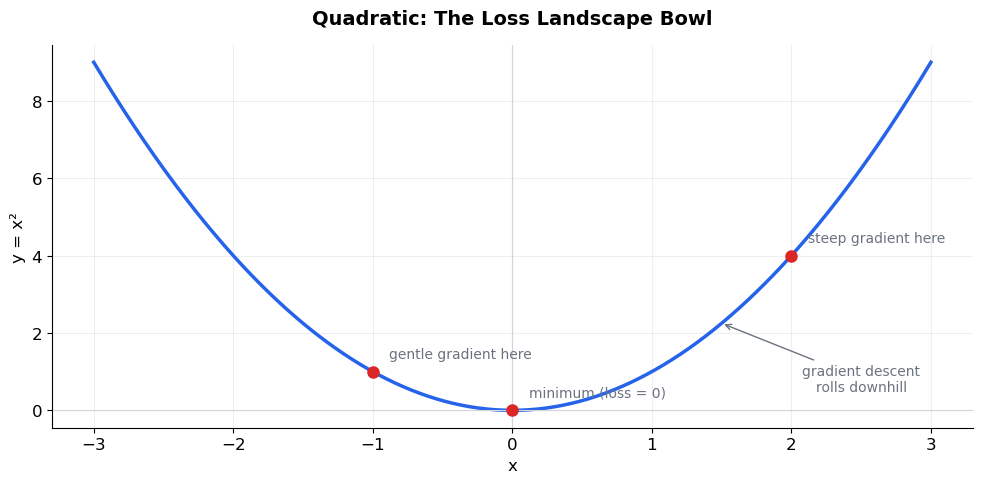

In [4]:
plot_function(
    func=lambda x: x**2,
    x_range=(-3, 3),
    title='Quadratic: The Loss Landscape Bowl',
    ylabel='y = x²',
    key_points=[(0, 0, 'minimum (loss = 0)'),
                (2, 4, 'steep gradient here'),
                (-1, 1, 'gentle gradient here')],
    annotations=[('gradient descent\nrolls downhill', (1.5, 2.25), (2.5, 0.5))],
)

## Exponential: y = eˣ

The "explosive growth" function. Small inputs give values near zero, but once x gets above 2-3, the output shoots up dramatically. This is the function hiding inside softmax — it's what makes softmax amplify differences between logits.

When one logit is much bigger than the others, eˣ blows up that gap. A logit of 4 gives e⁴ ≈ 55, while a logit of 1 gives e¹ ≈ 2.7. That 3-point difference in logits becomes a 20x difference after exponentiation. This is why softmax makes the network "pick a winner."

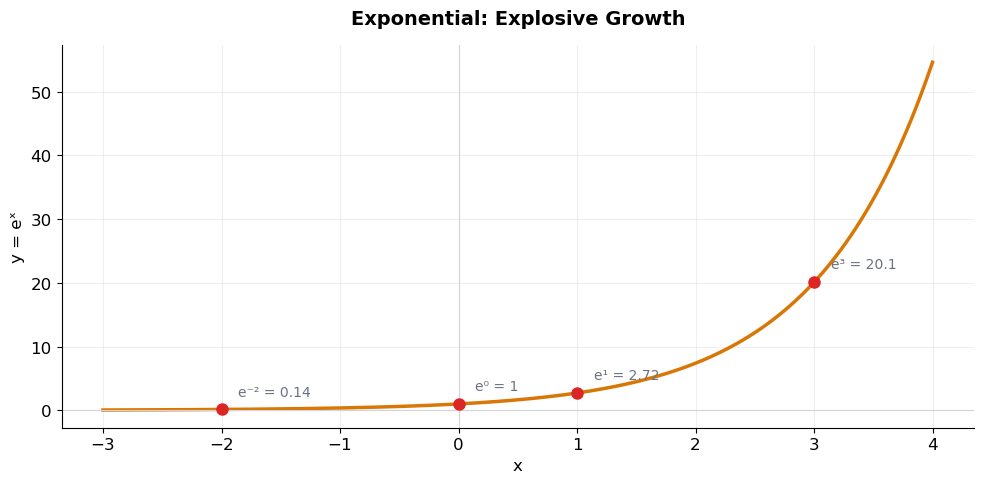

In [5]:
plot_function(
    func=np.exp,
    x_range=(-3, 4),
    title='Exponential: Explosive Growth',
    ylabel='y = eˣ',
    key_points=[(-2, np.exp(-2), f'e⁻² = {np.exp(-2):.2f}'),
                (0, 1, 'e⁰ = 1'),
                (1, np.e, f'e¹ = {np.e:.2f}'),
                (3, np.exp(3), f'e³ = {np.exp(3):.1f}')],
    color=COLORS['amber'],
)

## Logarithm: y = ln(x)

The inverse of exponential. Where exp grows explosively, log grows painfully slowly. It takes huge input values and compresses them down. But here's the ML-critical behavior: when the input approaches zero, log plummets to negative infinity.

This is exactly why cross-entropy loss uses `-log(p)`. If the model gives a tiny probability to the correct class (say p = 0.01), then `-log(0.01) = 4.6` — a massive loss value. If the model is confident and right (p = 0.95), then `-log(0.95) = 0.05` — basically zero loss. The log creates exactly the punishment curve we want.

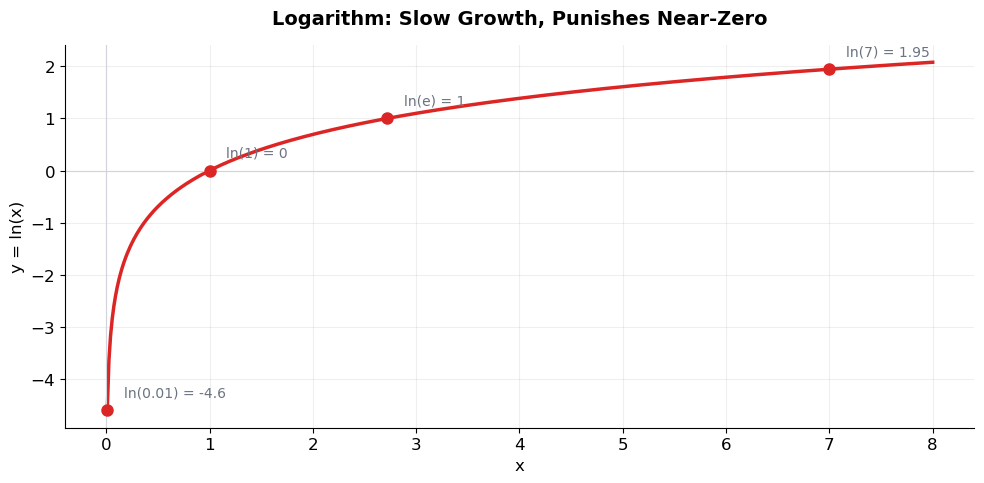

In [6]:
plot_function(
    func=lambda x: np.log(np.clip(x, 0.001, None)),
    x_range=(0.01, 8),
    title='Logarithm: Slow Growth, Punishes Near-Zero',
    ylabel='y = ln(x)',
    key_points=[(0.01, np.log(0.01), f'ln(0.01) = {np.log(0.01):.1f}'),
                (1, 0, 'ln(1) = 0'),
                (np.e, 1, f'ln(e) = 1'),
                (7, np.log(7), f'ln(7) = {np.log(7):.2f}')],
    color=COLORS['red'],
)

### Exponential and Logarithm: Two Sides of the Same Coin

These two functions undo each other: `ln(eˣ) = x` and `e^(ln(x)) = x`. On a graph, they're mirror images reflected across the line y = x.

In ML, this relationship is everywhere. Softmax uses exp to spread logits apart, then cross-entropy uses log to measure the result. They're designed to work together — the log "undoes" the exp and extracts a clean, interpretable loss value.

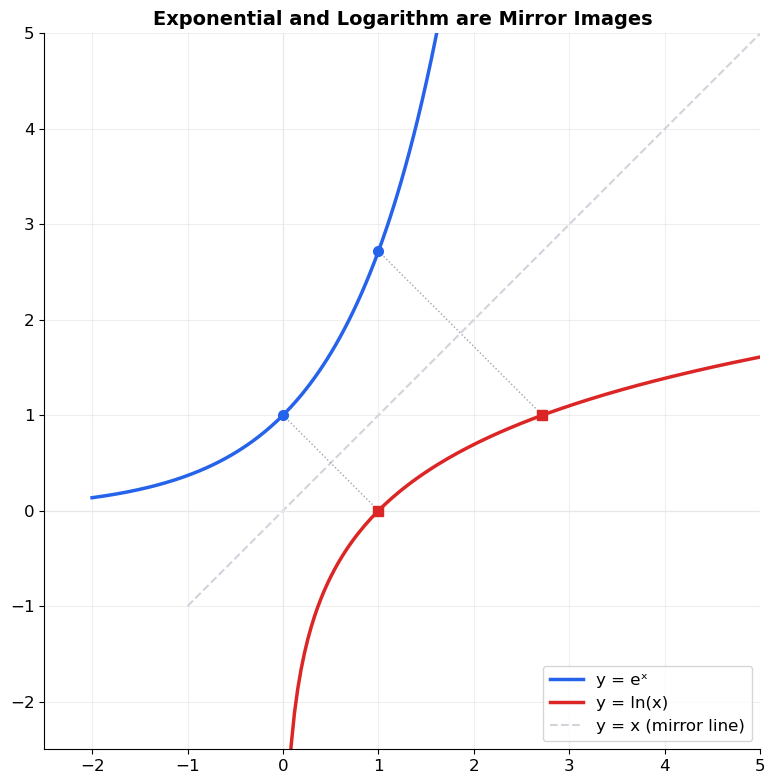

In [7]:
plot_exp_log_mirror()

## Sigmoid: σ(x) = 1 / (1 + e⁻ˣ)

The S-curve that squashes any real number into the range (0, 1). Large positive input? Output near 1. Large negative input? Output near 0. Zero? Exactly 0.5.

This makes it perfect for binary classification: the raw output of your last neuron (any number from -∞ to +∞) gets mapped to a probability. Notice the formula uses exp — sigmoid is built from the exponential function.

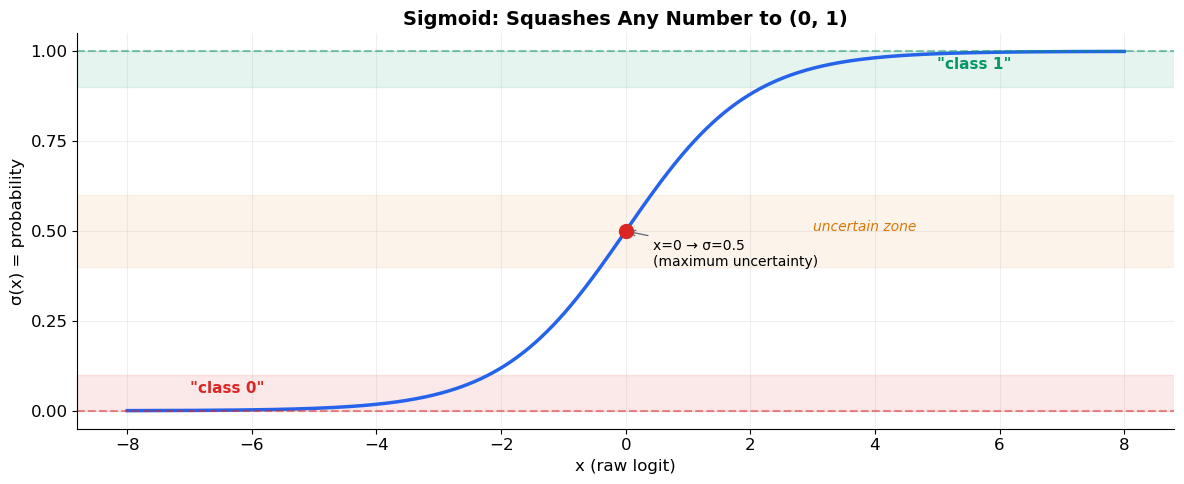

In [8]:
plot_sigmoid_anatomy()

## ReLU: max(0, x)

The simplest activation function and the default for hidden layers in modern networks. Below zero: output is zero (the neuron is "off"). Above zero: output equals input (the neuron passes the signal through unchanged).

Why is something this simple the standard? Because of its gradient. Sigmoid's gradient maxes out at 0.25 and vanishes for large/small inputs — after many layers, gradients shrink to nothing (the "vanishing gradient problem"). ReLU's gradient is either 0 or 1. When active, it passes gradients through perfectly, no matter how deep the network.

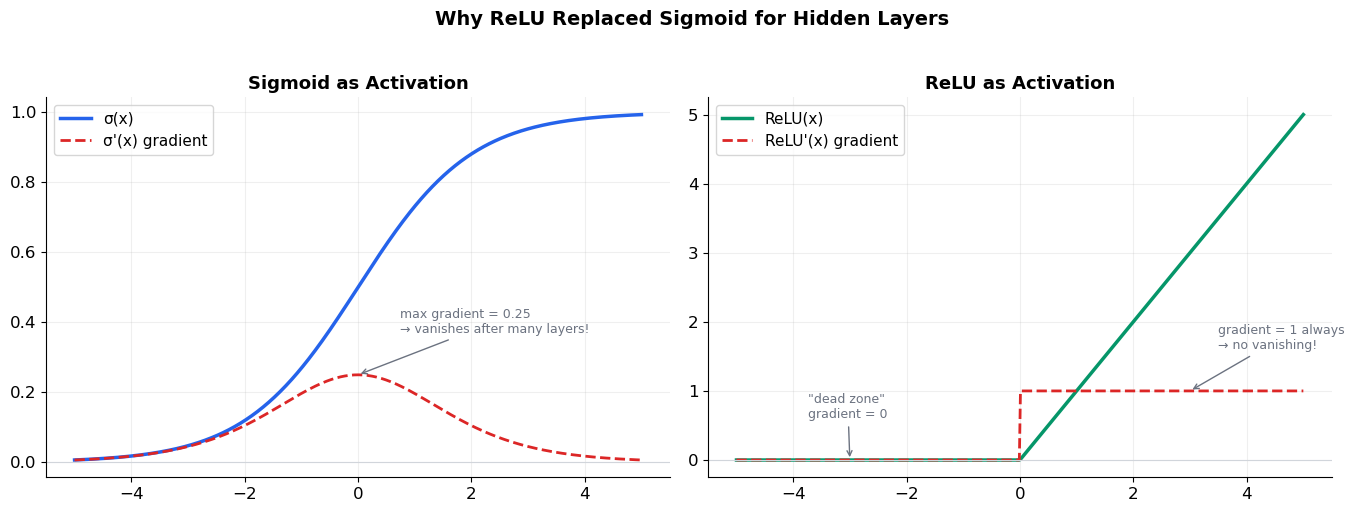

In [9]:
plot_relu_vs_sigmoid()

## Softmax: Probabilities That Sum to 1

Softmax isn't a curve you plot on a single axis — it's a function that takes a *vector* of logits and returns a *vector* of probabilities. The formula: `softmax(x_i) = e^(x_i) / sum(e^(x_j))`. Three steps: exponentiate each logit, then divide by the total.

The key behavior: softmax makes logits *compete*. When one logit is much larger, it hogs most of the probability. When logits are similar, probability spreads evenly. This is what makes it right for multi-class classification — the model must commit to one answer.

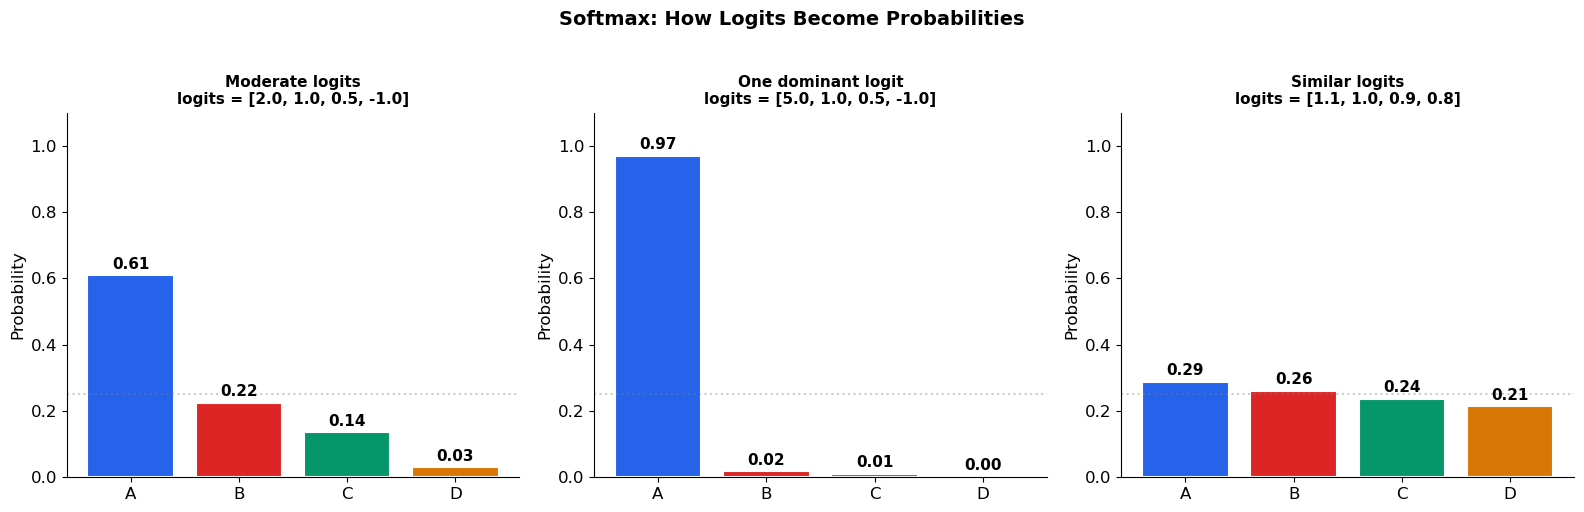

In [10]:
plot_softmax_behavior()

## The Cross-Entropy Punishment Curve

After softmax gives us probabilities, cross-entropy loss applies `-log(p)` to the probability of the correct class. This creates the exact punishment behavior we want: barely penalize confident correct predictions, but destroy the loss when the model is confident and wrong.

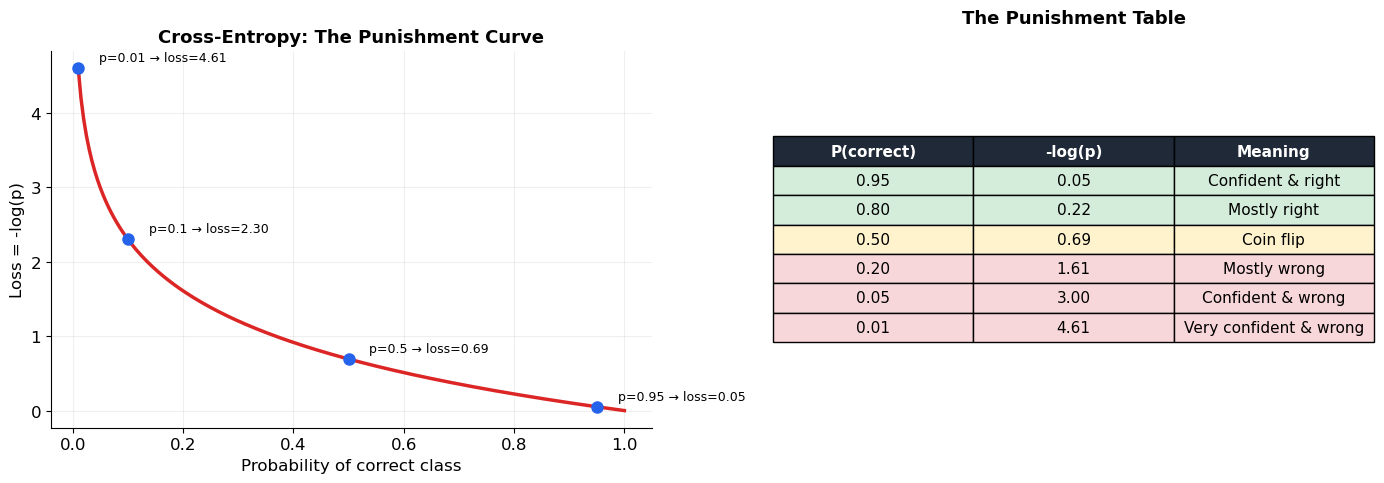

In [11]:
plot_neg_log_punishment()

## The Full Pipeline: Logits → Softmax → Loss

Here's how all these functions chain together in one forward pass. Raw logits come out of the last layer, exp amplifies the differences, dividing by the sum creates probabilities, and -log extracts the loss. Every function has a specific job in this pipeline.

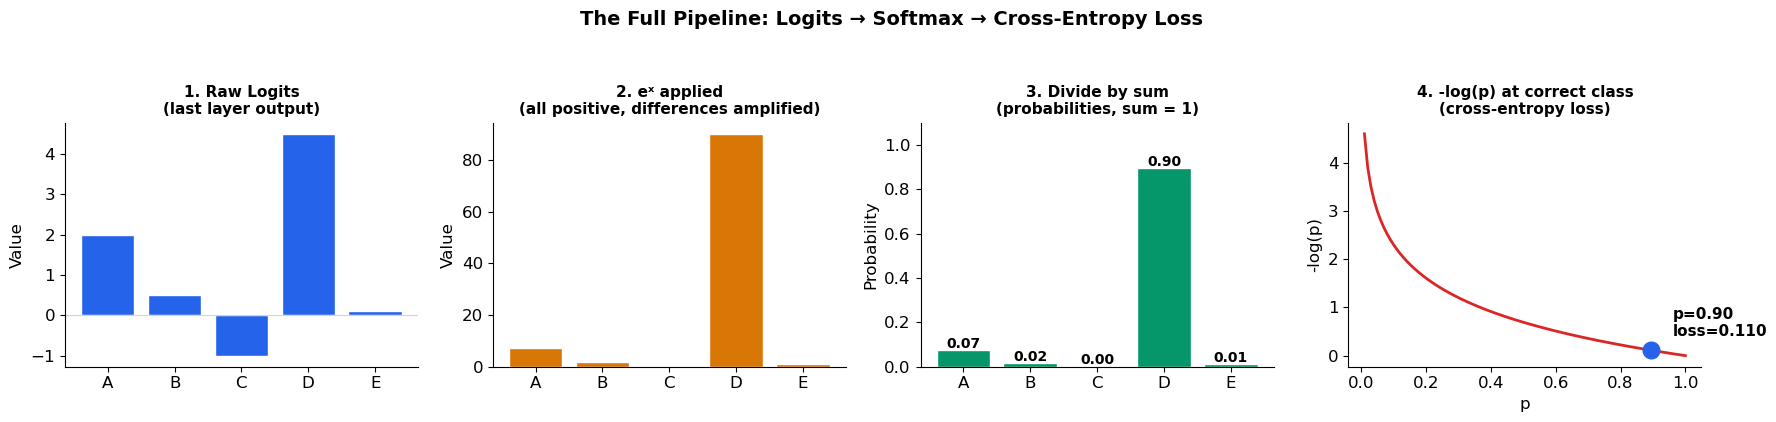

In [12]:
plot_ml_pipeline()

## Reference Card

All six functions at a glance. When you encounter one in a lesson, come back here to remind yourself of its shape and role.

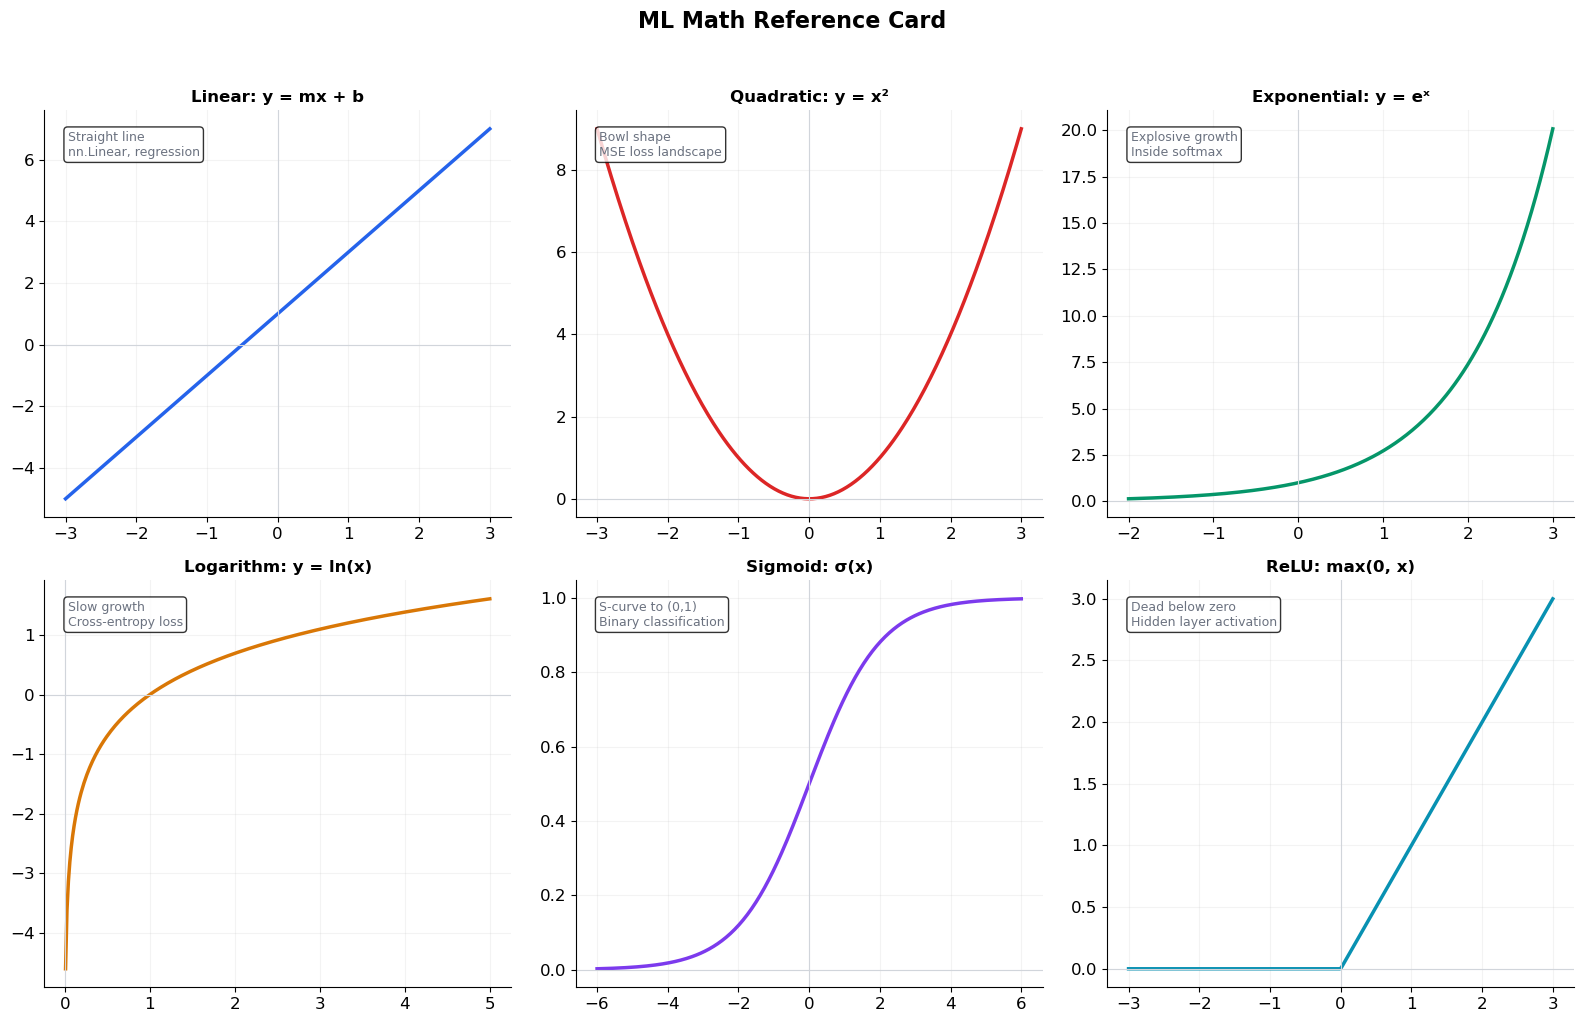

In [13]:
plot_reference_card()

## Where Each Function Appears in the Course

| Function | Formula | First appears | Shows up again |
|----------|---------|---------------|----------------|
| **Linear** | y = mx + b | L3 (regression) | Every `nn.Linear` layer |
| **Quadratic** | y = x² | L3 (MSE loss) | Loss landscapes in L5 |
| **Exponential** | y = eˣ | L4 (inside sigmoid) | Softmax in L9, attention in transformers |
| **Logarithm** | y = ln(x) | L4 (cross-entropy) | Every classification loss |
| **Sigmoid** | 1/(1+e⁻ˣ) | L4 (binary classification) | Gates in LSTMs, output activation |
| **ReLU** | max(0, x) | L5 (hidden layers) | Every neural network |
| **Softmax** | eˣi/Σeˣj | L9 (multi-class) | Attention weights in transformers |

The takeaway: exp amplifies, log compresses, sigmoid squashes to (0,1), softmax creates competition, ReLU gates on/off, and linear is the workhorse that does the actual computation. Every ML model is just these functions composed in clever ways.

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>